# Imports

In [163]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from tqdm import tqdm
from rasterio.features import rasterize, shapes
from rasterio.transform import from_bounds
import segmentation_models_pytorch as smp
import pytorch_lightning as pl
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
from shapely.geometry import shape
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import pandas as pd
import json
import glob
import cv2
from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects


# Paths & constants

In [164]:
DATA_ROOT      = Path("dataset/AOI_3_Paris_Train/AOI_3_Paris_Train")
IMG_DIR        = DATA_ROOT / "RGB-PanSharpen"
GEO_DIR        = DATA_ROOT / "geojson/buildings"
MASK_DIR       = DATA_ROOT / "masks"        # large-building masks (>1000 m²)
MASK_ALL_DIR   = DATA_ROOT / "masks_all"    # all-building masks
MASK_DIR.mkdir(exist_ok=True)
MASK_ALL_DIR.mkdir(exist_ok=True)

METRIC_CRS  = "EPSG:32631"   # UTM zone 31N — Paris
MIN_AREA_M2 = 1200
THRESHOLD   = 0.45


# Visualisation helper

In [ ]:
# fixes satellite images' washed-out look, removed bottom and top 2% of pixel values per band, then stretches the rest to [0, 1]

def stretch(img):
    """Percentile stretch per band — removes black borders and washed-out look."""
    out = np.zeros_like(img, dtype=np.float32)
    for i in range(3):
        band = img[:, :, i]
        lo   = np.percentile(band[band > 0], 2)
        hi   = np.percentile(band[band > 0], 98)
        out[:, :, i] = np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)
    return out


# Masks for large buildings only

In [165]:
def build_mask(img_path, geo_path, out_path, min_area=MIN_AREA_M2):
    """Rasterize only buildings > min_area m² (area measured in UTM)."""
    with rasterio.open(img_path) as src:
        meta          = src.meta.copy()
        img_crs       = src.crs
        img_transform = src.transform
        h, w          = src.height, src.width

    gdf = gpd.read_file(geo_path)
    if gdf.empty or gdf.geometry.isna().all():
        mask = np.zeros((h, w), dtype=np.uint8)
    else:
        if gdf.crs != img_crs:
            gdf = gdf.to_crs(img_crs)
        gdf_utm        = gdf.to_crs(METRIC_CRS)
        gdf["area_m2"] = gdf_utm.geometry.area
        large          = gdf[gdf["area_m2"] > min_area].copy()
        if large.empty:
            mask = np.zeros((h, w), dtype=np.uint8)
        else:
            large["geometry"] = large.geometry.buffer(0)
            large = large[large.geometry.is_valid]
            shapes_iter = [(geom.__geo_interface__, 1) for geom in large.geometry if geom is not None]
            mask = rasterize(shapes_iter, out_shape=(h, w), transform=img_transform,
                             fill=0, dtype=np.uint8, all_touched=True)

    meta.update(count=1, dtype="uint8", compress="lzw")
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(mask, 1)
    return mask.sum()

img_paths = sorted(IMG_DIR.glob("*.tif"))
geo_paths = sorted(GEO_DIR.glob("*.geojson"))
geo_lookup = {g.stem.split("_")[-1]: g for g in geo_paths}

total_large = 0
for img_path in tqdm(img_paths, desc="Generating large-building masks"):
    key = img_path.stem.split("_")[-1]
    if key not in geo_lookup:
        continue
    px = build_mask(img_path, geo_lookup[key], MASK_DIR / f"mask_{key}.tif")
    if px > 0:
        total_large += 1

print(f"Tiles with large buildings: {total_large}/{len(img_paths)}")


Generating large-building masks: 100%|██████████| 1148/1148 [00:05<00:00, 217.96it/s]

Tiles with large buildings: 96/1148


# Masks for all buildings

In [166]:
def build_mask_all_buildings(img_path, geo_path, out_path):
    """Rasterize every building regardless of size."""
    with rasterio.open(img_path) as src:
        meta          = src.meta.copy()
        img_crs       = src.crs
        img_transform = src.transform
        h, w          = src.height, src.width

    gdf = gpd.read_file(geo_path)
    if gdf.empty or gdf.geometry.isna().all():
        mask = np.zeros((h, w), dtype=np.uint8)
    else:
        if gdf.crs != img_crs:
            gdf = gdf.to_crs(img_crs)
        gdf["geometry"] = gdf.geometry.buffer(0)
        gdf = gdf[gdf.geometry.is_valid & gdf.geometry.notna()]
        if gdf.empty:
            mask = np.zeros((h, w), dtype=np.uint8)
        else:
            shapes_iter = [(geom.__geo_interface__, 1) for geom in gdf.geometry]
            mask = rasterize(shapes_iter, out_shape=(h, w), transform=img_transform,
                             fill=0, dtype=np.uint8, all_touched=True)

    meta.update(count=1, dtype="uint8", compress="lzw")
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(mask, 1)
    return mask.sum()

total_px = 0
for img_path in tqdm(img_paths, desc="Generating all-building masks"):
    key = img_path.stem.split("_")[-1]
    if key not in geo_lookup:
        continue
    total_px += build_mask_all_buildings(img_path, geo_lookup[key], MASK_ALL_DIR / f"mask_{key}.tif")

print(f"Done. Total building pixels: {total_px:,}")


Generating all-building masks: 100%|██████████| 1148/1148 [00:05<00:00, 218.49it/s]

Done. Total building pixels: 35,448,234


# Build tile index

In [ ]:
# dataset + caching tile index for faster loading in future runs

cache_file = MASK_ALL_DIR / "tile_index.json"

if cache_file.exists():
    print("Loading from cache...")
    with open(cache_file) as f:
        index = json.load(f)
else:
    print("Building tile index...")
    img_paths_idx, mask_paths_idx, has_building = [], [], []
    for mask_path in tqdm(sorted(MASK_ALL_DIR.glob("*.tif"))):
        key     = mask_path.stem.replace("mask_", "")
        matches = list(IMG_DIR.glob(f"*{key}.tif"))
        if not matches:
            continue
        with rasterio.open(mask_path) as src:
            has_bld = int(src.read(1).max() == 1)
        img_paths_idx.append(matches[0])
        mask_paths_idx.append(mask_path)
        has_building.append(has_bld)
    index = {"img_paths": [str(p) for p in img_paths_idx],
             "mask_paths": [str(p) for p in mask_paths_idx],
             "has_building": has_building}
    with open(cache_file, "w") as f:
        json.dump(index, f)

all_imgs     = [Path(p) for p in index["img_paths"]]
all_masks    = [Path(p) for p in index["mask_paths"]]
has_building = index["has_building"]
print(f"Total: {len(all_imgs)}  With buildings: {sum(has_building)}")


Loading from cache...
Total: 1148  With buildings: 633


# Train Split

In [168]:
(train_imgs, val_imgs,
 train_masks, val_masks,
 train_has, val_has) = train_test_split(
    all_imgs, all_masks, has_building,
    test_size=0.15, random_state=42
)
print(f"Train: {len(train_imgs)} tiles ({sum(train_has)} with buildings)")
print(f"Val  : {len(val_imgs)}   tiles ({sum(val_has)}  with buildings)")


Train: 975 tiles (534 with buildings)
Val  : 173   tiles (99  with buildings)


# Normalisation

In [ ]:
# normalises each image individually using per-image percentile stretch, same as stretch() but integrated with loading to avoid storing intermediate stretched images on disk

def load_and_normalize(img_path):
    """Per-image percentile stretch — used in BOTH training and inference."""
    with rasterio.open(img_path) as src:
        raw = src.read([1, 2, 3]).transpose(1, 2, 0).astype(np.float32)
    img = np.zeros_like(raw)
    for i in range(3):
        band = raw[:, :, i]
        lo   = np.percentile(band[band > 0], 2)
        hi   = np.percentile(band[band > 0], 98)
        img[:, :, i] = np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)
    return img.astype(np.float32)


# Dataset

In [170]:
class ParisBuildings(Dataset):
    def __init__(self, img_paths, mask_paths, has_building, patch=384, augment=True):
        self.pairs        = list(zip(img_paths, mask_paths))
        self.has_building = has_building
        self.augment      = augment
        self.patch        = patch
        self.tfm          = self._make_transform(augment)

    def _make_transform(self, augment):
        shared = [ToTensorV2()]
        if augment:
            return A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.Transpose(p=0.3),
                A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15,
                                   rotate_limit=30, p=0.5, border_mode=0),
                A.ColorJitter(brightness=0.3, contrast=0.3,
                              saturation=0.2, hue=0.05, p=0.5),
                A.GaussNoise(p=0.2),
            ] + shared)
        return A.Compose(shared)

    def _smart_crop(self, img, mask):
        p      = self.patch
        H, W   = mask.shape
        ys, xs = np.where(mask > 0)
        if len(ys) > 0 and np.random.rand() < 0.7:
            idx = np.random.randint(len(ys))
            cy, cx = ys[idx], xs[idx]
            y1 = int(np.clip(cy - p // 2, 0, H - p))
            x1 = int(np.clip(cx - p // 2, 0, W - p))
        else:
            y1 = np.random.randint(0, max(1, H - p))
            x1 = np.random.randint(0, max(1, W - p))
        return img[y1:y1+p, x1:x1+p], mask[y1:y1+p, x1:x1+p]

    def get_sampler_weights(self):
        weights = [5.0 if h else 1.0 for h in self.has_building]
        return torch.tensor(weights, dtype=torch.float)

    def __len__(self):
        return len(self.pairs) * (6 if self.augment else 2)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx % len(self.pairs)]
        img  = load_and_normalize(img_path)
        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)
        img, mask = self._smart_crop(img, mask)
        out = self.tfm(image=img, mask=mask)
        return out["image"], out["mask"].unsqueeze(0)


# Model (UNet)

In [171]:
class BuildingModel(pl.LightningModule):
    def __init__(self, lr=1e-3, pos_weight=3.0):
        super().__init__()
        self.save_hyperparameters()
        self.net = smp.Unet(
            encoder_name    = "efficientnet-b0",
            encoder_weights = "imagenet",
            in_channels     = 3,
            classes         = 1,
            activation      = None,
        )
        self.dice = smp.losses.DiceLoss(mode="binary", from_logits=True)
        self.bce  = smp.losses.SoftBCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight])
        )

    def forward(self, x):
        return self.net(x)

    def _step(self, batch, stage):
        imgs, masks = batch
        logits = self(imgs)
        loss   = self.dice(logits, masks) + self.bce(logits, masks)
        preds  = (logits.sigmoid() > 0.5).long()
        tp, fp, fn, tn = smp.metrics.get_stats(
            preds, masks.long(), mode="binary", threshold=None
        )
        iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro-imagewise")
        f1  = smp.metrics.f1_score( tp, fp, fn, tn, reduction="micro-imagewise")
        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log(f"{stage}_iou",  iou,  prog_bar=True, on_step=False, on_epoch=True)
        self.log(f"{stage}_f1",   f1,   prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def training_step(self, batch, _):   return self._step(batch, "train")
    def validation_step(self, batch, _): return self._step(batch, "val")

    def configure_optimizers(self):
        opt   = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=self.hparams.lr,
            total_steps=self.trainer.estimated_stepping_batches,
        )
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "interval": "step"}}


# Train

In [ ]:
STEPS_PER_EPOCH = 200

train_ds = ParisBuildings(train_imgs, train_masks, train_has, patch=384, augment=True)
val_ds   = ParisBuildings(val_imgs,   val_masks,   val_has,   patch=384, augment=False)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0, pin_memory=False)

model = BuildingModel(lr=1e-3, pos_weight=3.0)

trainer = pl.Trainer(
    max_epochs          = 60,
    accelerator         = "mps",   
    devices             = 1,
    precision           = "32",
    limit_train_batches = STEPS_PER_EPOCH,
    limit_val_batches   = 50,
    callbacks = [
        ModelCheckpoint(monitor="val_iou", mode="max",
                        filename="allbld-{epoch:02d}-{val_iou:.3f}",
                        save_top_k=1),
        EarlyStopping(monitor="val_iou", patience=15, mode="max"),
    ],
    log_every_n_steps = 10,
)

trainer.fit(model, train_loader, val_loader)
print("Best checkpoint:", trainer.checkpoint_callback.best_model_path)


/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Loading `train_dataloader` to estimate number of stepping batches.
/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers wh

┏━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net  │ Unet                  │  6.3 M │ train │     0 │
│ 1 │ dice │ DiceLoss              │      0 │ train │     0 │
│ 2 │ bce  │ SoftBCEWithLogitsLoss │      0 │ train │     0 │
└───┴──────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 6.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.3 M                                                                                                
Total estimated model params size (MB): 25                                                                         
Modules in train mode: 326                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: 
The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

Best checkpoint: /Users/aviralsharma/Documents/Coding/Python/detect_build/lightning_logs/version_12/checkpoints/allbld-epoch=26-val_iou=0.791.ckpt


# Load Checkpoint for Inference

In [ ]:
ckpts  = sorted(glob.glob("lightning_logs/version_*/checkpoints/allbld-*.ckpt"))
print("Available checkpoints:")
for c in ckpts: print(" ", c)

CKPT   = ckpts[-1]
model  = BuildingModel.load_from_checkpoint(CKPT)
model.eval()
device = torch.device("mps")   
model  = model.to(device)
print(f"\nLoaded: {CKPT}")


Available checkpoints:
  lightning_logs/version_11/checkpoints/allbld-epoch=26-val_iou=0.789.ckpt
  lightning_logs/version_12/checkpoints/allbld-epoch=26-val_iou=0.791.ckpt

Loaded: lightning_logs/version_12/checkpoints/allbld-epoch=26-val_iou=0.791.ckpt


# Watershed

In [ ]:
#  solved the earlier problem of adjacent buildings merging into one blob by using watershed-based instance separation, which identifies building centers as local maxima in the distance transform and then applies watershed to split connected regions based on these centers

def separate_instances(binary, min_distance=40, min_pixels=150):
    """
    Watershed-based instance separation.
    min_distance: building centres must be this many pixels apart to be split.
    min_pixels  : blobs smaller than this are discarded as noise.
    """
    binary_clean = remove_small_objects(
        binary.astype(bool), min_size=min_pixels
    ).astype(np.uint8)

    if binary_clean.sum() == 0:
        return np.zeros_like(binary, dtype=np.int32)

    dist    = ndimage.distance_transform_edt(binary_clean)
    coords  = peak_local_max(dist, min_distance=min_distance, labels=binary_clean)
    markers = np.zeros(dist.shape, dtype=np.int32)
    for i, (r, c) in enumerate(coords, start=1):
        markers[r, c] = i

    if markers.max() == 0:   # very elongated building — use centroid
        cy, cx = ndimage.center_of_mass(binary_clean)
        markers[int(cy), int(cx)] = 1

    return watershed(-dist, markers, mask=binary_clean)


# Sliding-window inference

In [ ]:
# Image → normalized → patch-wise model prediction → averaged probability map → thresholded mask → watershed splits buildings → polygons → area calculated → keep buildings >1000 m²

def predict_sliding_window(img, model, device, patch=384, stride=128):
    """Run overlapping patch inference and average the probability maps."""
    H, W, _   = img.shape
    prob_sum  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)
    ys = list(range(0, H - patch, stride)) + [H - patch]
    xs = list(range(0, W - patch, stride)) + [W - patch]
    for y in ys:
        for x in xs:
            crop   = img[y:y+patch, x:x+patch]
            tensor = torch.from_numpy(crop.transpose(2, 0, 1)).unsqueeze(0).to(device)
            with torch.no_grad():
                p = model(tensor).sigmoid().squeeze().cpu().numpy()
            prob_sum[y:y+patch, x:x+patch]  += p
            count_map[y:y+patch, x:x+patch] += 1
    return prob_sum / np.maximum(count_map, 1)


def predict_tile(img_path, min_area_m2=1000, threshold=0.45, visualize=True):
    """
    Full inference pipeline:
      1. Normalize image
      2. Sliding-window U-Net prediction
      3. Watershed instance separation
      4. Area filter — keep only > min_area_m2
      Returns GeoDataFrame of large buildings.
    """
    img = load_and_normalize(img_path)

    with rasterio.open(img_path) as src:
        tf   = src.transform
        crs  = src.crs
        h, w = src.height, src.width
        img_crs = src.crs

    prob   = predict_sliding_window(img, model, device, patch=384, stride=128)
    binary = np.ascontiguousarray((prob > threshold).astype(np.uint8))
    labels = separate_instances(binary, min_distance=40, min_pixels=150)

    all_buildings, large_buildings = [], []

    for label_id in np.unique(labels):
        if label_id == 0:
            continue
        instance_mask = np.ascontiguousarray((labels == label_id).astype(np.uint8))
        polys = [(shape(g), v) for g, v in shapes(instance_mask, transform=tf) if v == 1]
        if not polys:
            continue
        poly    = max(polys, key=lambda x: x[0].area)[0]
        gdf_tmp = gpd.GeoDataFrame(geometry=[poly], crs=img_crs).to_crs("EPSG:32631")
        area_m2 = gdf_tmp.geometry.area.values[0]
        all_buildings.append({"geometry": poly, "area_m2": round(area_m2, 1)})
        if area_m2 > min_area_m2:
            large_buildings.append({"geometry": poly, "area_m2": round(area_m2, 1)})

    def make_gdf(rows):
        if rows:
            return gpd.GeoDataFrame(rows, geometry="geometry", crs=crs)
        return gpd.GeoDataFrame(columns=["geometry", "area_m2"], geometry="geometry", crs=crs)

    all_gdf   = make_gdf(all_buildings)
    large_gdf = make_gdf(large_buildings)

    if visualize:
        instance_display = np.zeros((*binary.shape, 3), dtype=np.float32)
        colors = plt.cm.tab20(np.linspace(0, 1, max(int(labels.max()), 1) + 1))
        for lid in np.unique(labels):
            if lid == 0: continue
            instance_display[labels == lid] = colors[lid % 20][:3]

        all_mask = large_mask = np.zeros((h, w), dtype=np.uint8)
        if not all_gdf.empty:
            all_mask = rasterize([(g.__geo_interface__, 1) for g in all_gdf.geometry],
                                 out_shape=(h, w), transform=tf, fill=0, dtype=np.uint8)
        if not large_gdf.empty:
            large_mask = rasterize([(g.__geo_interface__, 1) for g in large_gdf.geometry],
                                   out_shape=(h, w), transform=tf, fill=0, dtype=np.uint8)

        fig, axes = plt.subplots(1, 5, figsize=(24, 5))
        axes[0].imshow(stretch(img));                      axes[0].set_title("Input");                         axes[0].axis("off")
        axes[1].imshow(prob, cmap="hot", vmin=0, vmax=1);  axes[1].set_title(f"Probability  max={prob.max():.3f}"); axes[1].axis("off")
        axes[2].imshow(stretch(img)); axes[2].imshow(instance_display, alpha=0.6); axes[2].set_title(f"Instances (n={len(all_gdf)})"); axes[2].axis("off")
        axes[3].imshow(stretch(img)); axes[3].imshow(all_mask,   cmap="Blues", alpha=0.5); axes[3].set_title(f"All buildings (n={len(all_gdf)})");  axes[3].axis("off")
        axes[4].imshow(stretch(img)); axes[4].imshow(large_mask, cmap="Reds",  alpha=0.5); axes[4].set_title(f">1000 m² (n={len(large_gdf)})");     axes[4].axis("off")
        plt.suptitle(Path(img_path).stem, fontsize=11)
        plt.tight_layout()
        plt.show()

    print(f"{Path(img_path).stem}: {len(all_gdf)} total | {len(large_gdf)} > {min_area_m2} m²")
    return large_gdf


# Run inference on a new image

/var/folders/ql/ktc8yw7d75s97rzwnfxlrhvm0000gn/T/ipykernel_10622/1492634294.py:7: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_clean = remove_small_objects(


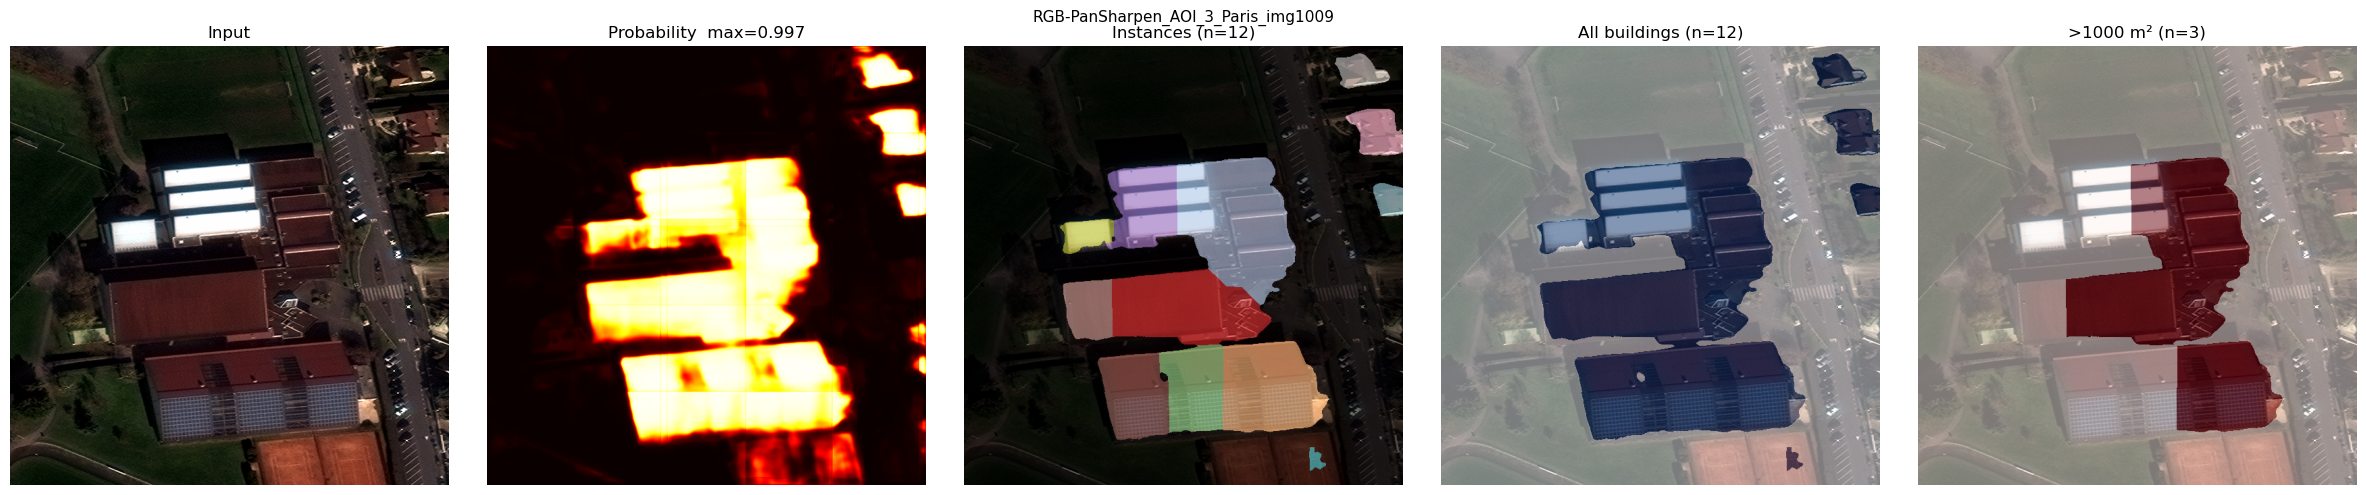

RGB-PanSharpen_AOI_3_Paris_img1009: 12 total | 3 > 1000 m²
Found 3 buildings > 1000 m²
   area_m2
0   1603.9
1   1036.3
2   1193.5
Saved → predictions/RGB-PanSharpen_AOI_3_Paris_img1009_pred.geojson


In [ ]:
OUTPUT_DIR = Path("predictions")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── To run on a new image ──
new_img = Path("dataset/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1009.tif")

gdf = predict_tile(new_img, min_area_m2=1000, threshold=0.45, visualize=True)

print(f"Found {len(gdf)} buildings > 1000 m²")
if not gdf.empty:
    print(gdf[["area_m2"]])
    gdf.to_file(OUTPUT_DIR / (new_img.stem + "_pred.geojson"), driver="GeoJSON")
    print(f"Saved → {OUTPUT_DIR / (new_img.stem + '_pred.geojson')}")


# Final evalution (pixel + tile level)

Evaluating: 100%|██████████| 173/173 [01:14<00:00,  2.33it/s]


 FINAL EVALUATION  —  Large buildings > 1000 m²
 Threshold : 0.45  |  Val tiles : 173

 PIXEL-LEVEL
  Accuracy  : 99.38%
  Precision : 60.12%
  Recall    : 77.09%
  F1        : 67.56%
  IoU       : 51.01%

 TILE-LEVEL
  Accuracy  : 96.53%
  Precision : 68.75%
  Recall    : 91.67%
  F1        : 78.57%

  TP=11  FP=5  FN=1  TN=156


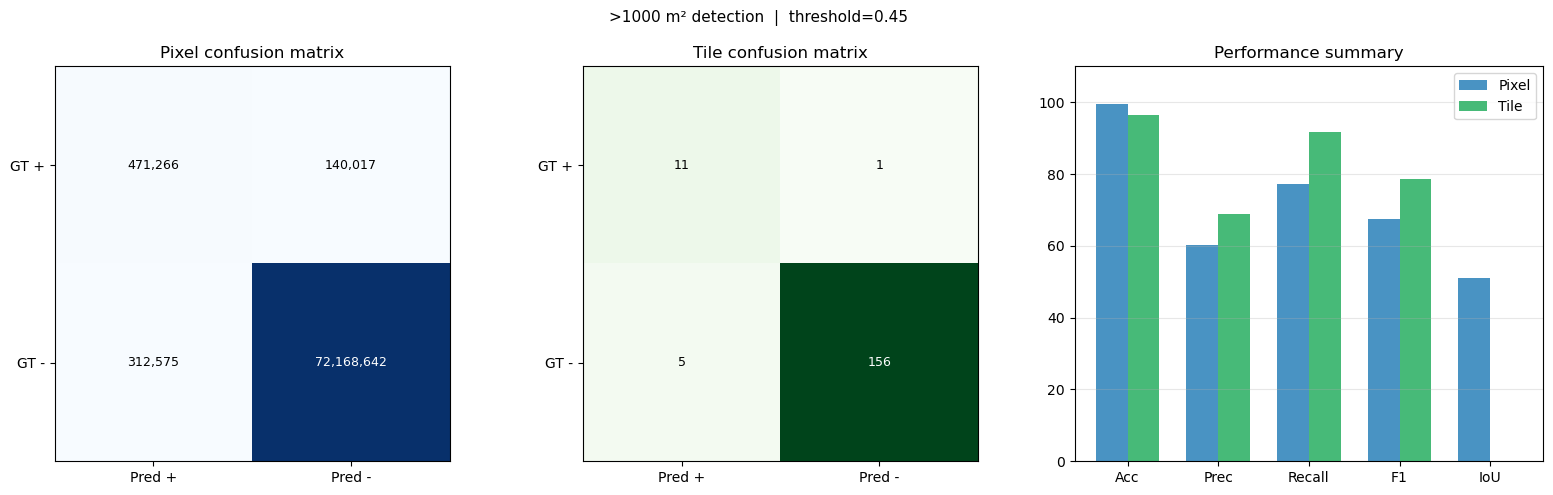

Saved → predictions/final_eval.png


In [ ]:
MASK_LARGE_DIR = DATA_ROOT / "masks"

val_masks_large = []
for p in val_masks:
    key   = p.stem.replace("mask_", "")
    large = MASK_LARGE_DIR / f"mask_{key}.tif"
    val_masks_large.append(large if large.exists() else p)

px_tp = px_fp = px_fn = px_tn = 0
tile_tp = tile_fp = tile_fn = tile_tn = 0
records = []

for img_path, gt_large_path, has_bld in tqdm(
        zip(val_imgs, val_masks_large, val_has), total=len(val_imgs), desc="Evaluating"):

    with rasterio.open(gt_large_path) as src:
        gt  = src.read(1).astype(np.float32)
        tf  = src.transform
        crs = src.crs

    gt_has_large    = gt.max() == 1
    img             = load_and_normalize(img_path)
    prob            = predict_sliding_window(img, model, device, patch=384, stride=128)
    binary          = np.ascontiguousarray((prob > THRESHOLD).astype(np.uint8))
    h, w            = binary.shape
    pred_large_mask = np.zeros((h, w), dtype=np.uint8)
    detected_areas  = []

    for geom_dict, val in shapes(binary, transform=tf):
        if val == 1:
            poly    = shape(geom_dict)
            gdf_tmp = gpd.GeoDataFrame(geometry=[poly], crs=crs).to_crs("EPSG:32631")
            area_m2 = gdf_tmp.geometry.area.values[0]
            if area_m2 > MIN_AREA_M2:
                detected_areas.append(round(area_m2, 1))
                burned = rasterize([(poly.__geo_interface__, 1)], out_shape=(h, w),
                                   transform=tf, fill=0, dtype=np.uint8)
                pred_large_mask = np.maximum(pred_large_mask, burned)

    pred_has_large = pred_large_mask.max() == 1
    tp = int(((pred_large_mask==1) & (gt==1)).sum())
    fp = int(((pred_large_mask==1) & (gt==0)).sum())
    fn = int(((pred_large_mask==0) & (gt==1)).sum())
    tn = int(((pred_large_mask==0) & (gt==0)).sum())
    px_tp += tp; px_fp += fp; px_fn += fn; px_tn += tn

    if     gt_has_large and     pred_has_large: tile_tp += 1
    elif not gt_has_large and   pred_has_large: tile_fp += 1
    elif   gt_has_large and not pred_has_large: tile_fn += 1
    else:                                       tile_tn += 1

    status = ("TP" if gt_has_large and pred_has_large else
              "FP" if not gt_has_large and pred_has_large else
              "FN" if gt_has_large and not pred_has_large else "TN")
    records.append({"tile": img_path.stem, "status": status,
                    "detected_areas": detected_areas,
                    "px_iou": tp / max(tp+fp+fn, 1)})

def safe_div(a, b): return a / b if b > 0 else 0.0

px_prec = safe_div(px_tp, px_tp+px_fp)
px_rec  = safe_div(px_tp, px_tp+px_fn)
px_f1   = safe_div(2*px_prec*px_rec, px_prec+px_rec)
px_iou  = safe_div(px_tp, px_tp+px_fp+px_fn)
px_acc  = safe_div(px_tp+px_tn, px_tp+px_fp+px_fn+px_tn)
tl_prec = safe_div(tile_tp, tile_tp+tile_fp)
tl_rec  = safe_div(tile_tp, tile_tp+tile_fn)
tl_f1   = safe_div(2*tl_prec*tl_rec, tl_prec+tl_rec)
tl_acc  = safe_div(tile_tp+tile_tn, tile_tp+tile_fp+tile_fn+tile_tn)

print("\n" + "="*55)
print(" FINAL EVALUATION  —  Large buildings > 1000 m²")
print("="*55)
print(f" Threshold : {THRESHOLD}  |  Val tiles : {len(val_imgs)}")
print("\n PIXEL-LEVEL")
print(f"  Accuracy  : {px_acc *100:.2f}%")
print(f"  Precision : {px_prec*100:.2f}%")
print(f"  Recall    : {px_rec *100:.2f}%")
print(f"  F1        : {px_f1  *100:.2f}%")
print(f"  IoU       : {px_iou *100:.2f}%")
print("\n TILE-LEVEL")
print(f"  Accuracy  : {tl_acc *100:.2f}%")
print(f"  Precision : {tl_prec*100:.2f}%")
print(f"  Recall    : {tl_rec *100:.2f}%")
print(f"  F1        : {tl_f1  *100:.2f}%")
print(f"\n  TP={tile_tp}  FP={tile_fp}  FN={tile_fn}  TN={tile_tn}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cm, title, cmap in [
    (axes[0], np.array([[px_tp, px_fn],[px_fp, px_tn]]), "Pixel confusion matrix", "Blues"),
    (axes[1], np.array([[tile_tp, tile_fn],[tile_fp, tile_tn]]), "Tile confusion matrix", "Greens"),
]:
    ax.imshow(cm, cmap=cmap)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred +","Pred -"]); ax.set_yticklabels(["GT +","GT -"])
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center", fontsize=9,
                    color="white" if cm[i,j] > cm.max()/2 else "black")

x = np.arange(5); w = 0.35
axes[2].bar(x-w/2, [px_acc*100, px_prec*100, px_rec*100, px_f1*100, px_iou*100],
            w, label="Pixel", color="#2980b9", alpha=0.85)
axes[2].bar(x+w/2, [tl_acc*100, tl_prec*100, tl_rec*100, tl_f1*100, 0],
            w, label="Tile",  color="#27ae60", alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(["Acc","Prec","Recall","F1","IoU"])
axes[2].set_ylim(0, 110); axes[2].legend(); axes[2].grid(axis="y", alpha=0.3)
axes[2].set_title("Performance summary")
plt.suptitle(f">1000 m² detection  |  threshold={THRESHOLD}", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_eval.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → predictions/final_eval.png")
